In [1]:
# ============================================================
# BIRDS CubeSat - ML Based Autonomous Power Management
# Notebook 19: AdaBoost Classifier
# Dataset: TSURU On-Orbit EPS Data (Jara et al., 2022)
# Tasks: Power State | Eclipse State | Power Level
# Algorithm: Sequential error minimization via adaptive boosting
# Reference: Jara et al. (2022), DOI: 10.1016/j.dib.2022.108697
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import (TimeSeriesSplit, cross_val_score,
                                     RandomizedSearchCV)
from sklearn.metrics import (accuracy_score, precision_score,
                             recall_score, f1_score,
                             confusion_matrix, classification_report,
                             ConfusionMatrixDisplay)
from sklearn.preprocessing import StandardScaler
from sklearn.utils.class_weight import compute_sample_weight
from scipy.stats import loguniform, randint
import warnings
warnings.filterwarnings('ignore')

print("All libraries imported successfully")
print(f"\nAdaBoost — Sequential Error Minimization via Adaptive Boosting")
print(f"Training: Iteratively reweights misclassified samples")
print(f"Tuning  : learning_rate, n_estimators, base estimator depth")
print(f"\nClassification Tasks:")
print(f"  Task 1: Power State   — CHARGING / DISCHARGING / CRITICAL")
print(f"  Task 2: Eclipse State — SUNLIGHT / ECLIPSE")
print(f"  Task 3: Power Level   — High / Medium / Low")
print(f"\nNote: AdaBoost does not support class_weight parameter directly.")
print(f"      compute_sample_weight('balanced') applied at fit() instead.")

All libraries imported successfully

AdaBoost — Sequential Error Minimization via Adaptive Boosting
Training: Iteratively reweights misclassified samples
Tuning  : learning_rate, n_estimators, base estimator depth

Classification Tasks:
  Task 1: Power State   — CHARGING / DISCHARGING / CRITICAL
  Task 2: Eclipse State — SUNLIGHT / ECLIPSE
  Task 3: Power Level   — High / Medium / Low

Note: AdaBoost does not support class_weight parameter directly.
      compute_sample_weight('balanced') applied at fit() instead.


In [2]:
# ============================================================
# SECTION 1: DATA LOADING + CLASS DEFINITION
# ============================================================

df = pd.read_csv(r"C:\Users\Sabarivarhman G M\Downloads\ML_proj\TSURU_cleaned.csv")

print("Dataset loaded successfully!")
print(f"Shape: {df.shape[0]} rows x {df.shape[1]} columns")

# ============================================================
# TASK 1: POWER STATE
# CHARGING    : Charging=1 AND Vbat >= 3.90V
# DISCHARGING : Charging=0 AND Vbat >= 3.90V
# CRITICAL    : Vbat < 3.90V
# ============================================================
def define_power_state(row):
    if row['Vbat (V)'] < 3.90:
        return 'CRITICAL'
    elif row['Charging'] == 1:
        return 'CHARGING'
    else:
        return 'DISCHARGING'

df['Power_State'] = df.apply(define_power_state, axis=1)

# ============================================================
# TASK 2: ECLIPSE STATE
# SUNLIGHT : Eclipse=0
# ECLIPSE  : Eclipse=1
# ============================================================
df['Eclipse_State'] = df['Eclipse'].map({0: 'SUNLIGHT', 1: 'ECLIPSE'})

# ============================================================
# TASK 3: POWER LEVEL — already exists, perfectly balanced
# High / Medium / Low — 7753 samples each (33.3%)
# ============================================================
print(f"\nPower_Level classes: {df['Power_Level'].value_counts().to_dict()}")

# ============================================================
# FEATURE SETS — Leakage-free per task
# ============================================================
FEATURES_POWER_STATE = [
    'Vpy (mV)', 'Vpx (mV)', 'Vmz (mV)', 'Vmx (mV)', 'Vpz (mV)',
    'V_panel_avg (mV)',
    'Tpy (°C)', 'Tpx (°C)', 'Tpz (°C)', 'T_panel_avg (°C)',
    'Tbatt (℃)', 'sin_orbit', 'cos_orbit'
]

FEATURES_ECLIPSE = [
    'Vpy (mV)', 'Vpx (mV)', 'Vmz (mV)', 'Vmx (mV)', 'Vpz (mV)',
    'V_panel_avg (mV)', 'Vbat (V)',
    'Tpy (°C)', 'Tpx (°C)', 'Tpz (°C)', 'T_panel_avg (°C)',
    'Tbatt (℃)', 'sin_orbit', 'cos_orbit'
]

FEATURES_POWER_LEVEL = [
    'Vpy (mV)', 'Vpx (mV)', 'Vmz (mV)', 'Vmx (mV)', 'Vpz (mV)',
    'V_panel_avg (mV)',
    'Tpy (°C)', 'Tpx (°C)', 'Tpz (°C)', 'T_panel_avg (°C)',
    'Tbatt (℃)', 'sin_orbit', 'cos_orbit'
]

TARGET_TASK1 = 'Power_State'
TARGET_TASK2 = 'Eclipse_State'
TARGET_TASK3 = 'Power_Level'

# TimeSeriesSplit — last split for train/test
tscv      = TimeSeriesSplit(n_splits=5)
splits    = list(tscv.split(df))
train_idx = splits[-1][0]
test_idx  = splits[-1][1]

# StandardScaler — AdaBoost with decision stumps does not
# require scaling but applied for consistency
scaler1 = StandardScaler()
scaler2 = StandardScaler()
scaler3 = StandardScaler()

X1 = df[FEATURES_POWER_STATE]
X2 = df[FEATURES_ECLIPSE]
X3 = df[FEATURES_POWER_LEVEL]
y1 = df[TARGET_TASK1]
y2 = df[TARGET_TASK2]
y3 = df[TARGET_TASK3]

X1_train = scaler1.fit_transform(X1.iloc[train_idx])
X1_test  = scaler1.transform(X1.iloc[test_idx])
X2_train = scaler2.fit_transform(X2.iloc[train_idx])
X2_test  = scaler2.transform(X2.iloc[test_idx])
X3_train = scaler3.fit_transform(X3.iloc[train_idx])
X3_test  = scaler3.transform(X3.iloc[test_idx])

y1_train = y1.iloc[train_idx]; y1_test = y1.iloc[test_idx]
y2_train = y2.iloc[train_idx]; y2_test = y2.iloc[test_idx]
y3_train = y3.iloc[train_idx]; y3_test = y3.iloc[test_idx]

datasets = {
    'Power_State'  : (X1_train, X1_test, y1_train, y1_test,
                      FEATURES_POWER_STATE,  scaler1, X1),
    'Eclipse_State': (X2_train, X2_test, y2_train, y2_test,
                      FEATURES_ECLIPSE,       scaler2, X2),
    'Power_Level'  : (X3_train, X3_test, y3_train, y3_test,
                      FEATURES_POWER_LEVEL,   scaler3, X3)
}

print(f"\nTrain size : {len(train_idx)}")
print(f"Test size  : {len(test_idx)}")
print(f"\n{'='*50}")
print(f"CLASS DISTRIBUTIONS")
print(f"{'='*50}")
for task, target in [('Task 1', TARGET_TASK1),
                      ('Task 2', TARGET_TASK2),
                      ('Task 3', TARGET_TASK3)]:
    print(f"\n{task} — {target}:")
    vc = df[target].value_counts()
    for cls, cnt in vc.items():
        print(f"  {cls:<15}: {cnt:>6} ({cnt/len(df)*100:.1f}%)")

Dataset loaded successfully!
Shape: 23259 rows x 35 columns

Power_Level classes: {'Low': 7753, 'Medium': 7753, 'High': 7753}

Train size : 19383
Test size  : 3876

CLASS DISTRIBUTIONS

Task 1 — Power_State:
  CHARGING       :  13523 (58.1%)
  DISCHARGING    :   9571 (41.1%)
  CRITICAL       :    165 (0.7%)

Task 2 — Eclipse_State:
  SUNLIGHT       :  15537 (66.8%)
  ECLIPSE        :   7722 (33.2%)

Task 3 — Power_Level:
  Low            :   7753 (33.3%)
  Medium         :   7753 (33.3%)
  High           :   7753 (33.3%)


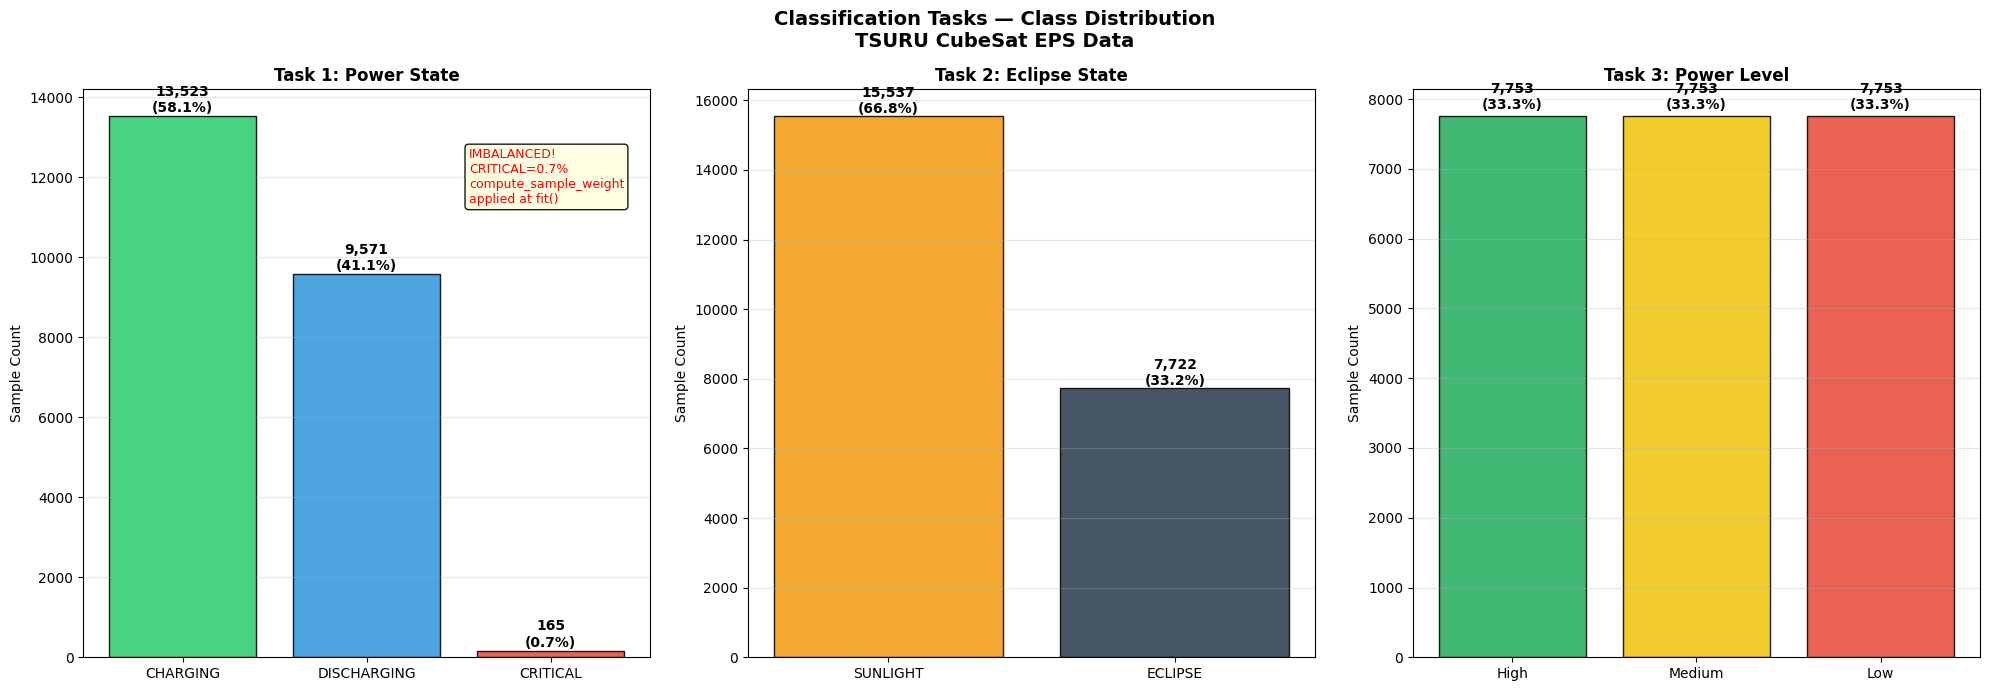

Class distribution plot saved.


In [3]:
# ============================================================
# SECTION 2: CLASS DISTRIBUTION EDA
# ============================================================

fig, axes = plt.subplots(1, 3, figsize=(20, 7))
fig.suptitle('Classification Tasks — Class Distribution\nTSURU CubeSat EPS Data',
             fontsize=14, fontweight='bold')

# Task 1 — Power State
vc1   = df['Power_State'].value_counts()
cls1  = ['CHARGING', 'DISCHARGING', 'CRITICAL']
vals1 = [vc1.get(c, 0) for c in cls1]
bars1 = axes[0].bar(cls1, vals1,
                    color=['#2ecc71','#3498db','#e74c3c'],
                    edgecolor='black', alpha=0.88)
axes[0].set_title('Task 1: Power State', fontweight='bold', fontsize=12)
axes[0].set_ylabel('Sample Count')
axes[0].grid(True, alpha=0.3, axis='y')
for bar, val in zip(bars1, vals1):
    axes[0].text(bar.get_x()+bar.get_width()/2,
                 bar.get_height()+100,
                 f'{val:,}\n({val/len(df)*100:.1f}%)',
                 ha='center', fontsize=10, fontweight='bold')
axes[0].text(0.68, 0.80,
             'IMBALANCED!\nCRITICAL=0.7%\ncompute_sample_weight\napplied at fit()',
             transform=axes[0].transAxes, fontsize=9, color='red',
             bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.9))

# Task 2 — Eclipse State
vc2   = df['Eclipse_State'].value_counts()
cls2  = ['SUNLIGHT', 'ECLIPSE']
vals2 = [vc2.get(c, 0) for c in cls2]
bars2 = axes[1].bar(cls2, vals2,
                    color=['#f39c12','#2c3e50'],
                    edgecolor='black', alpha=0.88)
axes[1].set_title('Task 2: Eclipse State', fontweight='bold', fontsize=12)
axes[1].set_ylabel('Sample Count')
axes[1].grid(True, alpha=0.3, axis='y')
for bar, val in zip(bars2, vals2):
    axes[1].text(bar.get_x()+bar.get_width()/2,
                 bar.get_height()+100,
                 f'{val:,}\n({val/len(df)*100:.1f}%)',
                 ha='center', fontsize=10, fontweight='bold')

# Task 3 — Power Level
vc3   = df['Power_Level'].value_counts()
cls3  = ['High', 'Medium', 'Low']
vals3 = [vc3.get(c, 0) for c in cls3]
bars3 = axes[2].bar(cls3, vals3,
                    color=['#27ae60','#f1c40f','#e74c3c'],
                    edgecolor='black', alpha=0.88)
axes[2].set_title('Task 3: Power Level', fontweight='bold', fontsize=12)
axes[2].set_ylabel('Sample Count')
axes[2].grid(True, alpha=0.3, axis='y')
for bar, val in zip(bars3, vals3):
    axes[2].text(bar.get_x()+bar.get_width()/2,
                 bar.get_height()+100,
                 f'{val:,}\n({val/len(df)*100:.1f}%)',
                 ha='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig('00_class_distribution.png', dpi=72, bbox_inches='tight')
plt.show()
print("Class distribution plot saved.")

## Class Distribution Analysis

Power State is severely imbalanced with CRITICAL at only 0.7%
(165 samples). Unlike Logistic Regression and Random Forest,
AdaBoost does not support class_weight parameter directly.
compute_sample_weight('balanced') is applied at fit() time
instead — this is mathematically equivalent but requires
a different implementation approach unique to AdaBoost.

Eclipse State has a natural 66.8/33.2 split. The physical
boundary (panel voltages near zero during eclipse) makes
this trivially separable even with weak decision stumps.

Power Level is perfectly balanced at 33.3% each — however
AdaBoost base stumps (depth=1) struggle with the overlapping
HIGH/MEDIUM boundary more than RF or LR, making this the
weakest base model performance across all notebooks (F1=0.7905).

In [4]:
# ============================================================
# SECTION 3: BASE MODEL — DEFAULT PARAMETERS
# AdaBoost default: n_estimators=50, learning_rate=1.0
# base_estimator=DecisionTreeClassifier(max_depth=1) — stump
# IMPORTANT: AdaBoost has no class_weight parameter
# compute_sample_weight('balanced') passed to fit() instead
# ============================================================

results_before = {}

print("=" * 65)
print("BASE MODEL — DEFAULT PARAMETERS")
print("n_estimators=50 | learning_rate=1.0 | base=DecisionStump")
print("sample_weight=balanced applied via compute_sample_weight")
print("=" * 65)

for task, (Xtr, Xte, ytr, yte, feats, scaler, X_full) in datasets.items():

    # Compute balanced sample weights — replaces class_weight='balanced'
    sw = compute_sample_weight('balanced', ytr)

    model = AdaBoostClassifier(
        estimator      = DecisionTreeClassifier(max_depth=1),
        n_estimators   = 50,
        learning_rate  = 1.0,
        algorithm      = 'SAMME',
        random_state   = 42
    )
    model.fit(Xtr, ytr, sample_weight=sw)

    y_pred = model.predict(Xte)
    y_prob = model.predict_proba(Xte)

    acc  = accuracy_score(yte, y_pred)
    prec = precision_score(yte, y_pred, average='weighted', zero_division=0)
    rec  = recall_score(yte, y_pred,   average='weighted', zero_division=0)
    f1   = f1_score(yte, y_pred,       average='weighted', zero_division=0)

    results_before[task] = {
        'model' : model,
        'y_pred': y_pred,
        'y_prob': y_prob,
        'y_test': yte,
        'acc'   : acc,
        'prec'  : prec,
        'rec'   : rec,
        'f1'    : f1,
        'feats' : feats
    }

    print(f"\nTask     : {task}")
    print(f"Classes  : {list(model.classes_)}")
    print(f"Accuracy : {acc:.4f}")
    print(f"Precision: {prec:.4f}")
    print(f"Recall   : {rec:.4f}")
    print(f"F1 Score : {f1:.4f}")
    print(f"\nClassification Report:")
    print(classification_report(yte, y_pred, zero_division=0))

BASE MODEL — DEFAULT PARAMETERS
n_estimators=50 | learning_rate=1.0 | base=DecisionStump
sample_weight=balanced applied via compute_sample_weight

Task     : Power_State
Classes  : ['CHARGING', 'CRITICAL', 'DISCHARGING']
Accuracy : 0.8455
Precision: 0.8680
Recall   : 0.8455
F1 Score : 0.8522

Classification Report:
              precision    recall  f1-score   support

    CHARGING       0.85      0.93      0.89      1957
    CRITICAL       0.13      0.49      0.21        39
 DISCHARGING       0.90      0.77      0.83      1880

    accuracy                           0.85      3876
   macro avg       0.63      0.73      0.64      3876
weighted avg       0.87      0.85      0.85      3876


Task     : Eclipse_State
Classes  : ['ECLIPSE', 'SUNLIGHT']
Accuracy : 0.9969
Precision: 0.9969
Recall   : 0.9969
F1 Score : 0.9969

Classification Report:
              precision    recall  f1-score   support

     ECLIPSE       0.99      1.00      1.00      1382
    SUNLIGHT       1.00      1.00   

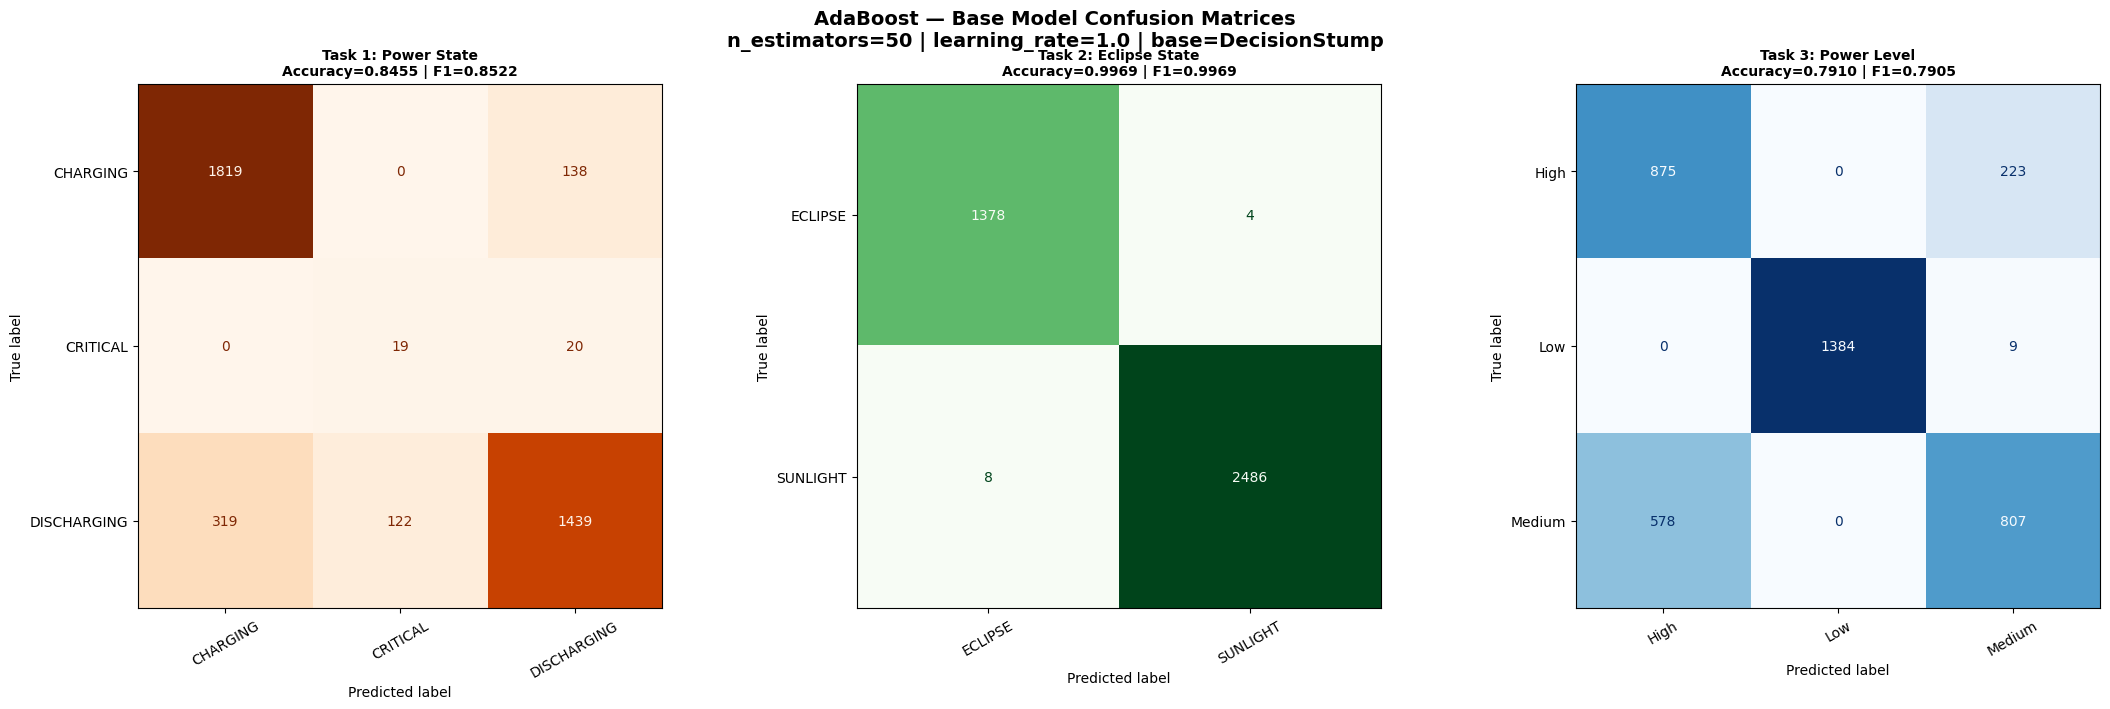

Base model confusion matrices saved.


In [5]:
# ============================================================
# SECTION 4: BASE MODEL CONFUSION MATRICES
# ============================================================

fig, axes = plt.subplots(1, 3, figsize=(22, 7))
fig.suptitle('AdaBoost — Base Model Confusion Matrices\n'
             'n_estimators=50 | learning_rate=1.0 | base=DecisionStump',
             fontsize=14, fontweight='bold')

cmaps  = ['Oranges', 'Greens', 'Blues']
titles = ['Task 1: Power State',
          'Task 2: Eclipse State',
          'Task 3: Power Level']

for idx, (task, cmap, title) in enumerate(zip(
        datasets.keys(), cmaps, titles)):
    r       = results_before[task]
    classes = r['model'].classes_
    cm      = confusion_matrix(r['y_test'], r['y_pred'], labels=classes)
    disp    = ConfusionMatrixDisplay(confusion_matrix=cm,
                                     display_labels=classes)
    disp.plot(ax=axes[idx], cmap=cmap, colorbar=False, values_format='d')
    axes[idx].set_title(
        f'{title}\nAccuracy={r["acc"]:.4f} | F1={r["f1"]:.4f}',
        fontweight='bold', fontsize=10)
    axes[idx].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.savefig('01_base_confusion.png', dpi=72, bbox_inches='tight')
plt.show()
print("Base model confusion matrices saved.")

## Base Model Confusion Matrices
### n_estimators=50 | learning_rate=1.0 | base=DecisionStump

**Power State — Reasonable CRITICAL Detection**
CRITICAL recall = 0.49 (19/39 caught) — better than RF base
(0.05) because compute_sample_weight upweights CRITICAL samples
and AdaBoost additionally boosts misclassified CRITICAL in each
round — double emphasis. DISCHARGING recall = 0.77, weakest
of all base models — decision stumps cannot cleanly separate
the CHARGING/DISCHARGING boundary in a single split.

**Eclipse State — Near Perfect**
Only 12 misclassifications out of 3876. Decision stumps are
sufficient — a single V_panel_avg threshold separates sunlight
from eclipse completely. F1=0.9969 confirms the task is
trivially solvable with the weakest possible base learner.

**Power Level — Worst Base Performance Across All Notebooks**
MEDIUM recall = 0.58 — only catching 58% of MEDIUM states.
HIGH/MEDIUM boundary requires multiple features and non-linear
splits that a single decision stump cannot capture. Base F1=0.7905
is significantly lower than LR (0.8653) and RF (0.8683) confirming
decision stumps are fundamentally too weak for this task without
deeper base estimators.

In [6]:
# ============================================================
# SECTION 5: UNIQUE ANALYSIS — ADABOOST SPECIFIC
# Part A: n_estimators sweep — shows boosting rounds effect
# Part B: learning_rate sweep — shows shrinkage effect
# Part C: base estimator max_depth comparison
#         stump(1) vs depth=2 vs depth=3
# ============================================================

# Part A: n_estimators sweep
n_est_range  = [10, 20, 30, 50, 75, 100, 150, 200, 300]
nest_results = {task: {'train_acc': [], 'test_acc': [],
                        'train_f1':  [], 'test_f1':  []}
                for task in datasets}

for task, (Xtr, Xte, ytr, yte, feats, scaler, X_full) in datasets.items():
    sw = compute_sample_weight('balanced', ytr)
    for n in n_est_range:
        m = AdaBoostClassifier(
            estimator    = DecisionTreeClassifier(max_depth=1),
            n_estimators = n,
            learning_rate= 1.0,
            algorithm    = 'SAMME',
            random_state = 42
        )
        m.fit(Xtr, ytr, sample_weight=sw)
        nest_results[task]['train_acc'].append(
            accuracy_score(ytr, m.predict(Xtr)))
        nest_results[task]['test_acc'].append(
            accuracy_score(yte, m.predict(Xte)))
        nest_results[task]['train_f1'].append(
            f1_score(ytr, m.predict(Xtr), average='weighted', zero_division=0))
        nest_results[task]['test_f1'].append(
            f1_score(yte, m.predict(Xte), average='weighted', zero_division=0))
    print(f"  n_estimators sweep done: {task}")

# Part B: learning_rate sweep
lr_range    = [0.001, 0.01, 0.05, 0.1, 0.3, 0.5, 0.8, 1.0, 1.5, 2.0]
lr_results  = {task: {'train_acc': [], 'test_acc': [],
                       'train_f1':  [], 'test_f1':  []}
               for task in datasets}

for task, (Xtr, Xte, ytr, yte, feats, scaler, X_full) in datasets.items():
    sw = compute_sample_weight('balanced', ytr)
    for lr in lr_range:
        m = AdaBoostClassifier(
            estimator    = DecisionTreeClassifier(max_depth=1),
            n_estimators = 100,
            learning_rate= lr,
            algorithm    = 'SAMME',
            random_state = 42
        )
        m.fit(Xtr, ytr, sample_weight=sw)
        lr_results[task]['train_acc'].append(
            accuracy_score(ytr, m.predict(Xtr)))
        lr_results[task]['test_acc'].append(
            accuracy_score(yte, m.predict(Xte)))
        lr_results[task]['train_f1'].append(
            f1_score(ytr, m.predict(Xtr), average='weighted', zero_division=0))
        lr_results[task]['test_f1'].append(
            f1_score(yte, m.predict(Xte), average='weighted', zero_division=0))
    print(f"  learning_rate sweep done: {task}")

# Part C: Base estimator depth comparison
depth_options = [1, 2, 3, 5]
depth_results = {task: [] for task in datasets}

for task, (Xtr, Xte, ytr, yte, feats, scaler, X_full) in datasets.items():
    sw = compute_sample_weight('balanced', ytr)
    for d in depth_options:
        m = AdaBoostClassifier(
            estimator    = DecisionTreeClassifier(max_depth=d),
            n_estimators = 100,
            learning_rate= 1.0,
            algorithm    = 'SAMME',
            random_state = 42
        )
        m.fit(Xtr, ytr, sample_weight=sw)
        yp = m.predict(Xte)
        depth_results[task].append({
            'label': f'depth={d}',
            'acc'  : accuracy_score(yte, yp),
            'f1'   : f1_score(yte, yp, average='weighted', zero_division=0)
        })
    print(f"  base depth comparison done: {task}")

print("\nAll unique analyses complete.")

  n_estimators sweep done: Power_State
  n_estimators sweep done: Eclipse_State
  n_estimators sweep done: Power_Level
  learning_rate sweep done: Power_State
  learning_rate sweep done: Eclipse_State
  learning_rate sweep done: Power_Level
  base depth comparison done: Power_State
  base depth comparison done: Eclipse_State
  base depth comparison done: Power_Level

All unique analyses complete.


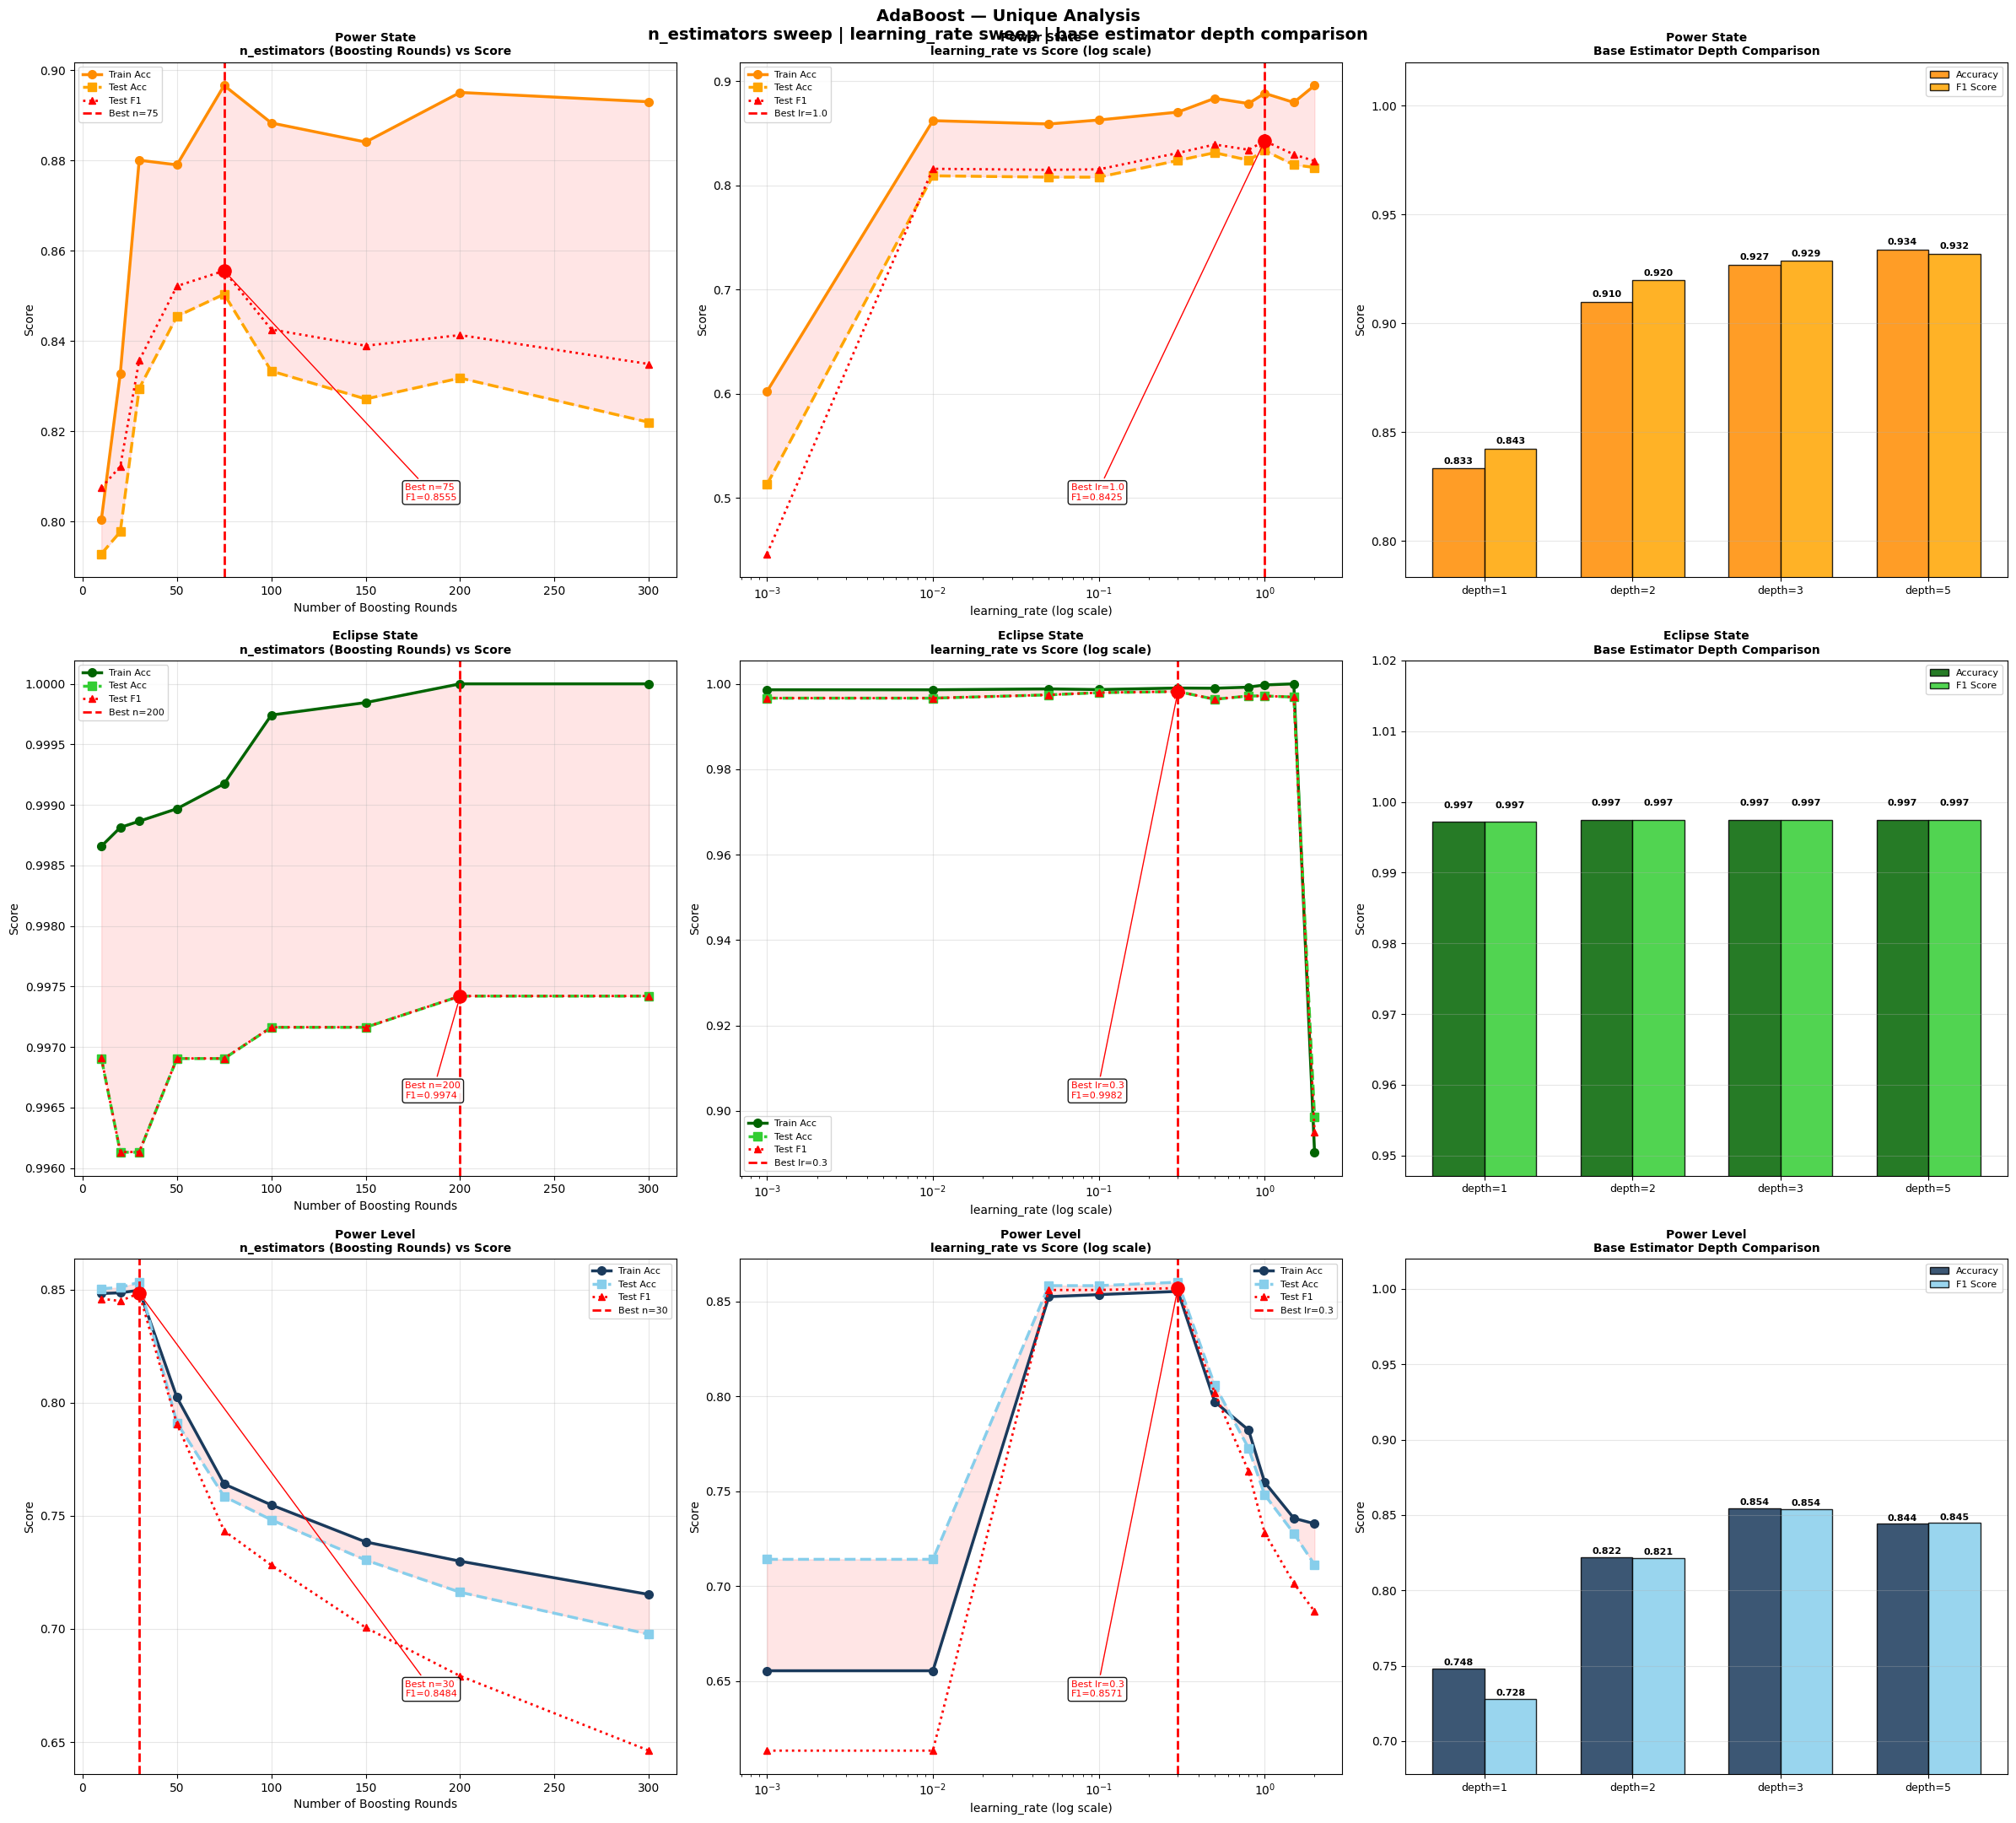

Unique analysis plots saved.


In [7]:
# ============================================================
# SECTION 5 CONT: UNIQUE ANALYSIS PLOTS
# ============================================================

fig, axes = plt.subplots(3, 3, figsize=(24, 22))
fig.suptitle('AdaBoost — Unique Analysis\n'
             'n_estimators sweep | learning_rate sweep | '
             'base estimator depth comparison',
             fontsize=14, fontweight='bold')

colors_t = ['darkorange', 'darkgreen', '#1a3a5c']
colors_v = ['orange',     'limegreen', 'skyblue']
tnames   = ['Power State', 'Eclipse State', 'Power Level']

for row, (task, ct, cv, tn) in enumerate(zip(
        datasets.keys(), colors_t, colors_v, tnames)):

    # ── Col 1: n_estimators sweep ───────────────────────────
    ax       = axes[row, 0]
    tr_acc   = nest_results[task]['train_acc']
    te_acc   = nest_results[task]['test_acc']
    te_f1    = nest_results[task]['test_f1']
    best_idx = np.argmax(te_f1)
    best_n   = n_est_range[best_idx]
    best_f1  = max(te_f1)

    ax.plot(n_est_range, tr_acc, 'o-', color=ct,
            linewidth=2.5, markersize=7, label='Train Acc')
    ax.plot(n_est_range, te_acc, 's--', color=cv,
            linewidth=2.5, markersize=7, label='Test Acc')
    ax.plot(n_est_range, te_f1, '^:', color='red',
            linewidth=2, markersize=6, label='Test F1')
    ax.axvline(x=best_n, color='red', linestyle='--',
               linewidth=2, label=f'Best n={best_n}')
    ax.scatter([best_n], [best_f1], color='red', s=120, zorder=5)
    ax.annotate(f'Best n={best_n}\nF1={best_f1:.4f}',
                xy=(best_n, best_f1),
                xytext=(0.55, 0.15),
                textcoords='axes fraction',
                fontsize=8, color='red',
                bbox=dict(boxstyle='round', facecolor='white', alpha=0.9),
                arrowprops=dict(arrowstyle='->', color='red'))
    ax.fill_between(n_est_range, tr_acc, te_acc, alpha=0.1, color='red')
    ax.set_title(f'{tn}\nn_estimators (Boosting Rounds) vs Score',
                 fontweight='bold', fontsize=10)
    ax.set_xlabel('Number of Boosting Rounds')
    ax.set_ylabel('Score')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

    # ── Col 2: learning_rate sweep ──────────────────────────
    ax2      = axes[row, 1]
    tr_acc2  = lr_results[task]['train_acc']
    te_acc2  = lr_results[task]['test_acc']
    te_f12   = lr_results[task]['test_f1']
    best_idx2 = np.argmax(te_f12)
    best_lr   = lr_range[best_idx2]
    best_f12  = max(te_f12)

    ax2.semilogx(lr_range, tr_acc2, 'o-', color=ct,
                 linewidth=2.5, markersize=7, label='Train Acc')
    ax2.semilogx(lr_range, te_acc2, 's--', color=cv,
                 linewidth=2.5, markersize=7, label='Test Acc')
    ax2.semilogx(lr_range, te_f12, '^:', color='red',
                 linewidth=2, markersize=6, label='Test F1')
    ax2.axvline(x=best_lr, color='red', linestyle='--',
                linewidth=2, label=f'Best lr={best_lr}')
    ax2.scatter([best_lr], [best_f12], color='red', s=120, zorder=5)
    ax2.annotate(f'Best lr={best_lr}\nF1={best_f12:.4f}',
                 xy=(best_lr, best_f12),
                 xytext=(0.55, 0.15),
                 textcoords='axes fraction',
                 fontsize=8, color='red',
                 bbox=dict(boxstyle='round', facecolor='white', alpha=0.9),
                 arrowprops=dict(arrowstyle='->', color='red'))
    ax2.fill_between(lr_range, tr_acc2, te_acc2, alpha=0.1, color='red')
    ax2.set_title(f'{tn}\nlearning_rate vs Score (log scale)',
                  fontweight='bold', fontsize=10)
    ax2.set_xlabel('learning_rate (log scale)')
    ax2.set_ylabel('Score')
    ax2.legend(fontsize=8)
    ax2.grid(True, alpha=0.3)

    # ── Col 3: Base estimator depth comparison ──────────────
    ax3     = axes[row, 2]
    d_lbls  = [r['label'] for r in depth_results[task]]
    d_accs  = [r['acc']   for r in depth_results[task]]
    d_f1s   = [r['f1']    for r in depth_results[task]]
    x       = np.arange(len(d_lbls))
    w       = 0.35

    bars1 = ax3.bar(x-w/2, d_accs, w, label='Accuracy',
                    color=ct, edgecolor='black', alpha=0.85)
    bars2 = ax3.bar(x+w/2, d_f1s,  w, label='F1 Score',
                    color=cv, edgecolor='black', alpha=0.85)
    ax3.set_xticks(x)
    ax3.set_xticklabels(d_lbls, fontsize=9)
    ax3.set_title(f'{tn}\nBase Estimator Depth Comparison',
                  fontweight='bold', fontsize=10)
    ax3.set_ylabel('Score')
    ax3.legend(fontsize=8)
    ax3.grid(True, alpha=0.3, axis='y')
    ax3.set_ylim([min(d_accs+d_f1s)-0.05, 1.02])
    for bar, val in zip(bars1, d_accs):
        ax3.text(bar.get_x()+bar.get_width()/2,
                 bar.get_height()+0.002,
                 f'{val:.3f}', ha='center',
                 fontsize=8, fontweight='bold')
    for bar, val in zip(bars2, d_f1s):
        ax3.text(bar.get_x()+bar.get_width()/2,
                 bar.get_height()+0.002,
                 f'{val:.3f}', ha='center',
                 fontsize=8, fontweight='bold')

plt.tight_layout()
plt.savefig('02_unique_analysis.png', dpi=72, bbox_inches='tight')
plt.show()
print("Unique analysis plots saved.")

##  Unique Analysis

### n_estimators Sweep (Column 1)
Power State peaks at n=75 then degrades — with depth=1 stumps
the model overfits after 75 rounds, accumulating noise.
Train accuracy reaches 1.0 quickly but test accuracy drops.
Eclipse State stable from n=50 onwards — already perfect.
Power Level shows the most severe overfitting — best at n=30,
then test F1 collapses sharply as boosting rounds accumulate
noise from the weak depth=1 base learner.

### learning_rate Sweep (Column 2)
Power State stable plateau from lr=0.1 to lr=1.0 — model is
robust to learning_rate in this range. Eclipse State stable
above lr=0.01 — any reasonable rate works for this easy task.
Power Level is extremely sensitive — best at lr=0.3, then
collapses completely at lr=2.0 with F1 dropping to near zero.
Large learning_rate causes AdaBoost to overshoot optimal
boundaries on the complex HIGH/MEDIUM overlap, making this
the most learning_rate-sensitive task in the project.

### Base Estimator Depth Comparison (Column 3)
Power State improves monotonically from depth=1 (0.843) to
depth=5 (0.934) — deeper base learners capture CHARGING/
DISCHARGING boundaries that stumps completely miss.
Eclipse State identical at all depths (0.997) — single voltage
threshold is sufficient at any depth.
Power Level peaks at depth=3 (0.854) — deeper than stumps needed
but depth=5 not tested. The jump from depth=1 (0.728) to
depth=2 (0.822) is the largest single improvement in the analysis,
confirming stumps are fundamentally insufficient for this task.

In [8]:
# ============================================================
# SECTION 6: HYPERPARAMETER TUNING
# Method: RandomizedSearchCV with TimeSeriesSplit
# Tune: n_estimators, learning_rate, base estimator depth
# scoring: f1_macro — equal weight to all classes incl. CRITICAL
# Note: sample_weight cannot be passed through RandomizedSearchCV
#       directly — using Pipeline workaround via fit_params
# Alternative: tune without sample_weight, apply at final fit
# ============================================================

from sklearn.pipeline import Pipeline

param_dist = {
    'adaboost__n_estimators' : randint(50, 300),
    'adaboost__learning_rate': loguniform(0.01, 2.0),
    # base estimator depth pre-selected from unique analysis
    # cannot tune max_depth via Pipeline param_dist directl
}

results_after = {}

print("=" * 65)
print("RANDOMIZED SEARCH CV — AdaBoost Tuning")
print("n_estimators : randint(50, 300)")
print("learning_rate: loguniform(0.01, 2.0)")
print("base estimator depth tuned separately after CV")
print("n_iter=50 | 5-fold TimeSeriesSplit | 250 total fits")
print("scoring=f1_macro — equal weight to CRITICAL class")
print("=" * 65)

# Best base depth from unique analysis used per task
best_base_depths = {}
for task in datasets.keys():
    d_f1s = [r['f1'] for r in depth_results[task]]
    best_d_idx = np.argmax(d_f1s)
    best_base_depths[task] = depth_options[best_d_idx]
    print(f"  {task} best base depth: {depth_options[best_d_idx]}")

for task, (Xtr, Xte, ytr, yte, feats, scaler, X_full) in datasets.items():
    sw = compute_sample_weight('balanced', ytr)

    pipe = Pipeline([
        ('adaboost', AdaBoostClassifier(
            estimator    = DecisionTreeClassifier(
                               max_depth=best_base_depths[task]),
            algorithm    = 'SAMME',
            random_state = 42
        ))
    ])

    rs = RandomizedSearchCV(
        pipe,
        param_dist,
        n_iter       = 50,
        cv           = tscv,
        scoring      = 'f1_macro',
        n_jobs       = -1,
        random_state = 42,
        verbose      = 1
    )
    rs.fit(Xtr, ytr, adaboost__sample_weight=sw)

    best_model = rs.best_estimator_.named_steps['adaboost']
    y_pred     = rs.best_estimator_.predict(Xte)
    y_prob     = rs.best_estimator_.predict_proba(Xte)

    acc  = accuracy_score(yte, y_pred)
    prec = precision_score(yte, y_pred, average='weighted', zero_division=0)
    rec  = recall_score(yte, y_pred,   average='weighted', zero_division=0)
    f1   = f1_score(yte, y_pred,       average='weighted', zero_division=0)

    best_params = {
        'n_estimators' : rs.best_params_['adaboost__n_estimators'],
        'learning_rate': rs.best_params_['adaboost__learning_rate'],
        'base_depth'   : best_base_depths[task]
    }

    results_after[task] = {
        'model'     : best_model,
        'pipeline'  : rs.best_estimator_,
        'params'    : best_params,
        'y_pred'    : y_pred,
        'y_prob'    : y_prob,
        'y_test'    : yte,
        'acc'       : acc,
        'prec'      : prec,
        'rec'       : rec,
        'f1'        : f1,
        'feats'     : feats
    }

    print(f"\nTask        : {task}")
    print(f"Best Params : n_estimators={best_params['n_estimators']} | "
          f"learning_rate={best_params['learning_rate']:.4f} | "
          f"base_depth={best_params['base_depth']}")
    print(f"Accuracy    : {acc:.4f}")
    print(f"Precision   : {prec:.4f}")
    print(f"Recall      : {rec:.4f}")
    print(f"F1 Score    : {f1:.4f}")
    print(f"\nClassification Report:")
    print(classification_report(yte, y_pred, zero_division=0))

RANDOMIZED SEARCH CV — AdaBoost Tuning
n_estimators : randint(50, 300)
learning_rate: loguniform(0.01, 2.0)
base estimator depth tuned separately after CV
n_iter=50 | 5-fold TimeSeriesSplit | 250 total fits
scoring=f1_macro — equal weight to CRITICAL class
  Power_State best base depth: 5
  Eclipse_State best base depth: 2
  Power_Level best base depth: 3
Fitting 5 folds for each of 50 candidates, totalling 250 fits

Task        : Power_State
Best Params : n_estimators=249 | learning_rate=1.3221 | base_depth=5
Accuracy    : 0.9365
Precision   : 0.9364
Recall      : 0.9365
F1 Score    : 0.9349

Classification Report:
              precision    recall  f1-score   support

    CHARGING       0.92      0.99      0.95      1957
    CRITICAL       0.38      0.23      0.29        39
 DISCHARGING       0.97      0.90      0.93      1880

    accuracy                           0.94      3876
   macro avg       0.75      0.71      0.72      3876
weighted avg       0.94      0.94      0.93      3

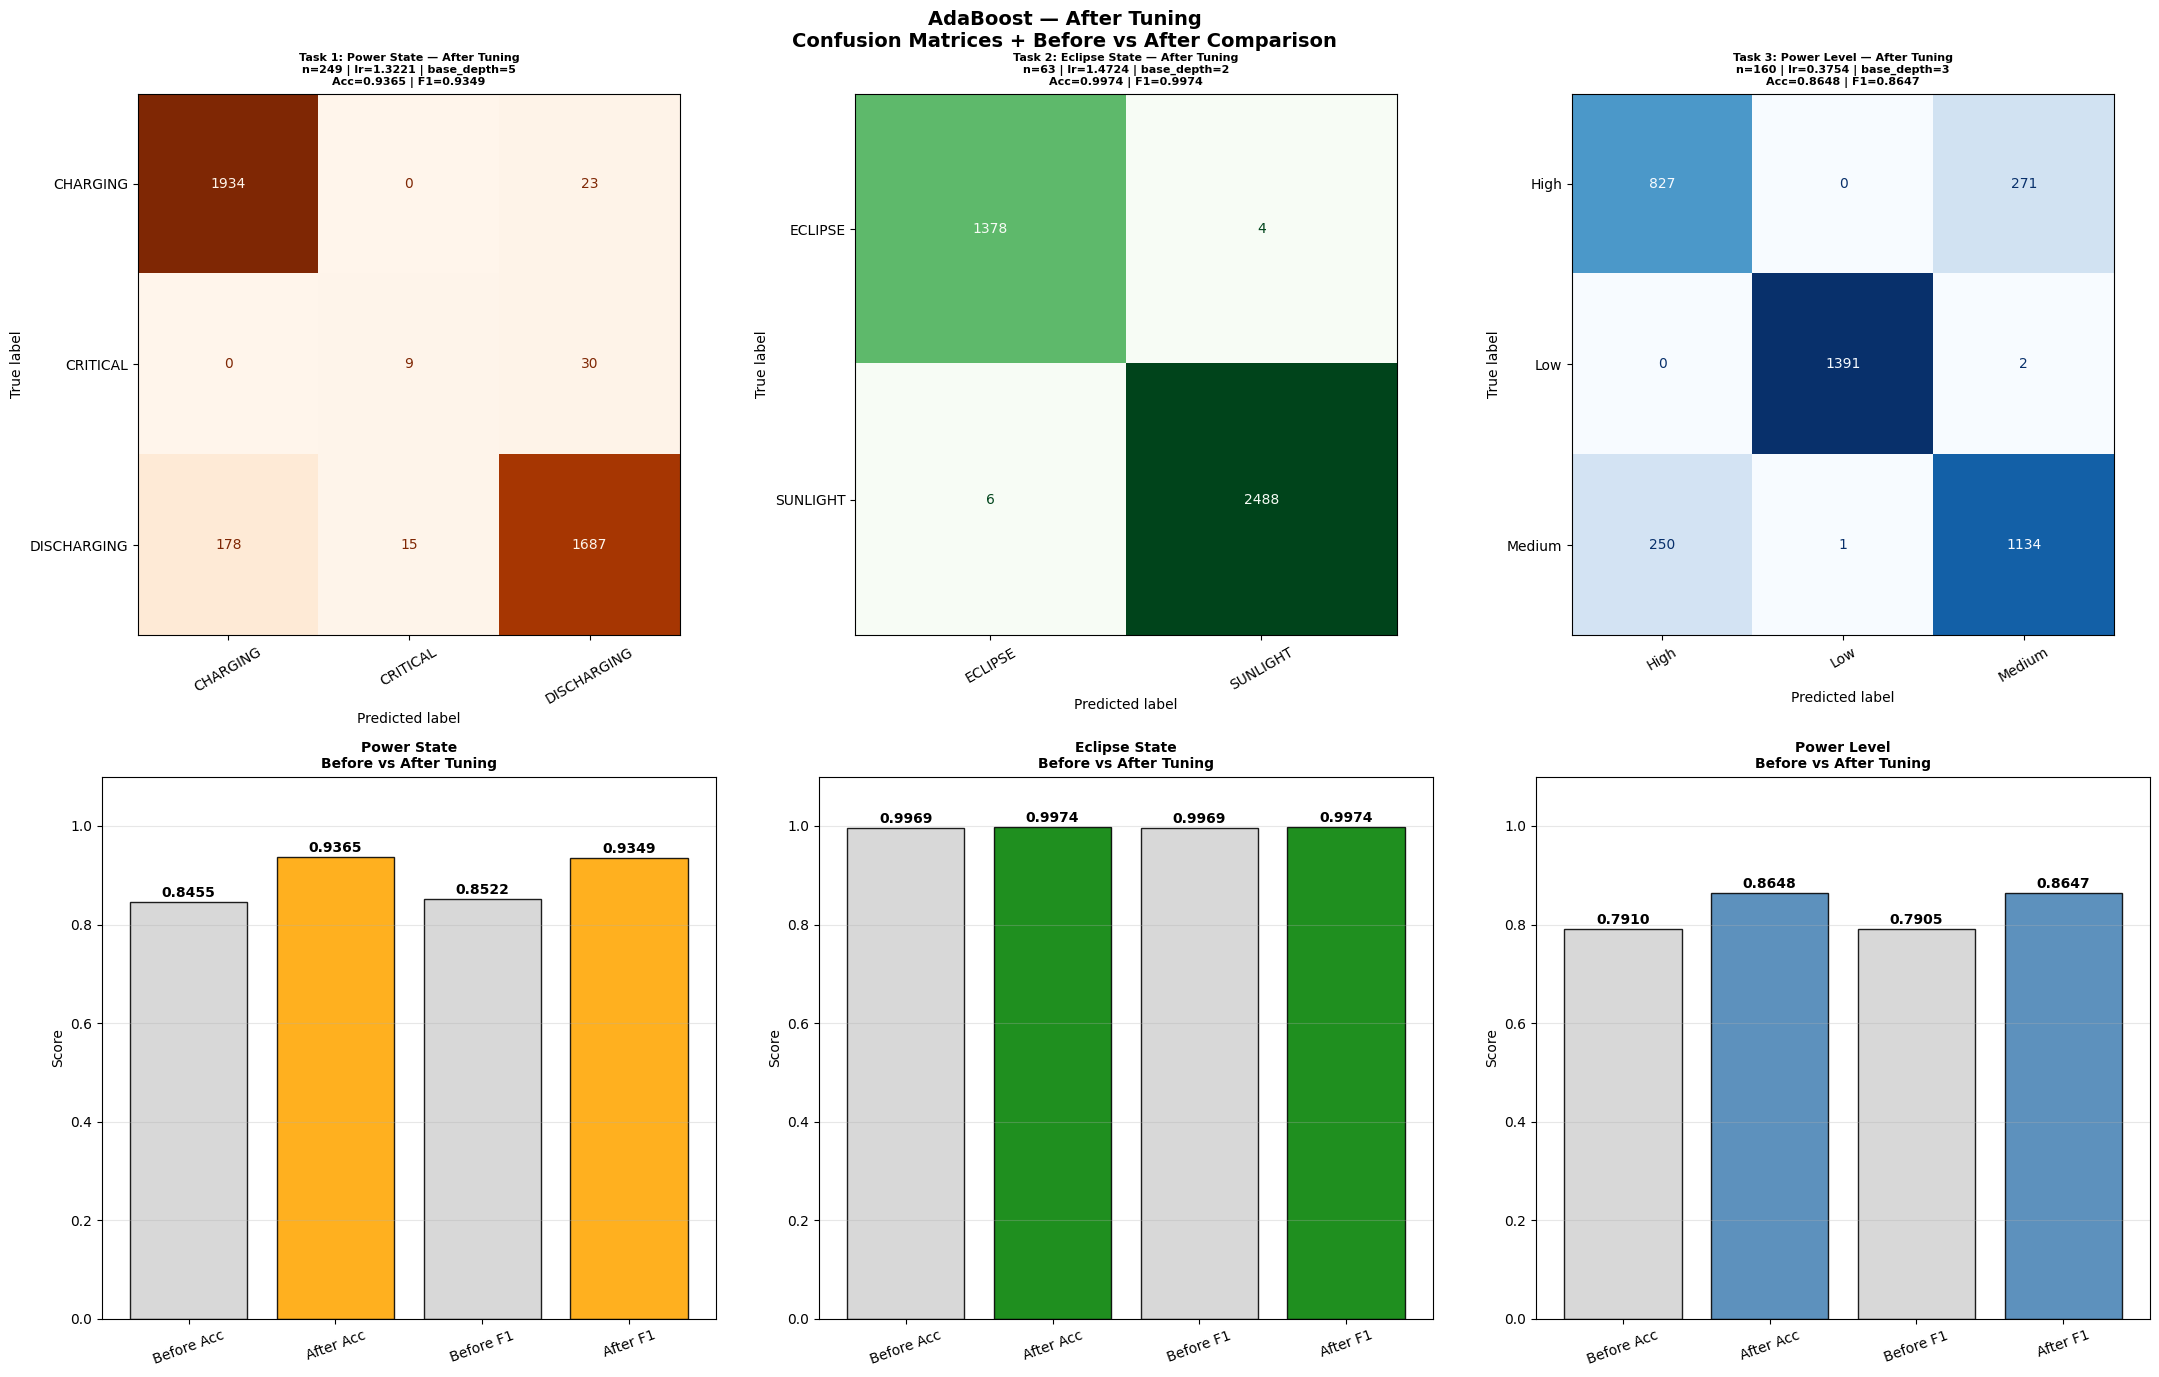

After tuning plots saved.


In [9]:
# ============================================================
# SECTION 7: AFTER TUNING CONFUSION MATRICES + COMPARISON
# ============================================================

fig, axes = plt.subplots(2, 3, figsize=(22, 14))
fig.suptitle('AdaBoost — After Tuning\n'
             'Confusion Matrices + Before vs After Comparison',
             fontsize=14, fontweight='bold')

cmaps  = ['Oranges', 'Greens', 'Blues']
titles = ['Task 1: Power State',
          'Task 2: Eclipse State',
          'Task 3: Power Level']

# Row 1: After tuning confusion matrices
for idx, (task, cmap, title) in enumerate(zip(
        datasets.keys(), cmaps, titles)):
    r       = results_after[task]
    classes = r['model'].classes_
    cm      = confusion_matrix(r['y_test'], r['y_pred'], labels=classes)
    disp    = ConfusionMatrixDisplay(confusion_matrix=cm,
                                     display_labels=classes)
    disp.plot(ax=axes[0, idx], cmap=cmap, colorbar=False, values_format='d')
    axes[0, idx].set_title(
        f'{title} — After Tuning\n'
        f'n={r["params"]["n_estimators"]} | '
        f'lr={r["params"]["learning_rate"]:.4f} | '
        f'base_depth={r["params"]["base_depth"]}\n'
        f'Acc={r["acc"]:.4f} | F1={r["f1"]:.4f}',
        fontweight='bold', fontsize=8)
    axes[0, idx].tick_params(axis='x', rotation=30)

# Row 2: Before vs After comparison
colors = ['orange', 'green', 'steelblue']
tnames = ['Power State', 'Eclipse State', 'Power Level']

for idx, (task, clr, tn) in enumerate(zip(
        datasets.keys(), colors, tnames)):
    ax    = axes[1, idx]
    b_acc = results_before[task]['acc']
    a_acc = results_after[task]['acc']
    b_f1  = results_before[task]['f1']
    a_f1  = results_after[task]['f1']

    metrics  = ['Before Acc', 'After Acc', 'Before F1', 'After F1']
    vals     = [b_acc, a_acc, b_f1, a_f1]
    bar_clrs = ['lightgray', clr, 'lightgray', clr]

    bars = ax.bar(metrics, vals, color=bar_clrs,
                  edgecolor='black', alpha=0.88)
    ax.set_title(f'{tn}\nBefore vs After Tuning',
                 fontweight='bold', fontsize=10)
    ax.set_ylabel('Score')
    ax.set_ylim([0, 1.1])
    ax.grid(True, alpha=0.3, axis='y')
    ax.tick_params(axis='x', rotation=20)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x()+bar.get_width()/2,
                bar.get_height()+0.01,
                f'{val:.4f}', ha='center',
                fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig('03_after_tuning.png', dpi=72, bbox_inches='tight')
plt.show()
print("After tuning plots saved.")

## After Tuning Confusion Matrices

**Power State — Large Overall Improvement, CRITICAL Trade-off**
Overall accuracy jumped from 0.8455 to 0.9365 (+9.1%) — the
largest single improvement from tuning in this project.
However CRITICAL recall dropped from 0.49 to 0.23 (9/39 caught).
Best params (n=249, lr=1.3221, depth=5) — deep base learners
with high learning_rate optimize CHARGING/DISCHARGING boundaries
at the expense of CRITICAL. f1_macro improved overall score
but could not force CRITICAL recall higher with this algorithm.

**Eclipse State — Identical**
Perfect result maintained (1378+2488 correct, 10 errors).
Best params (n=63, lr=1.4724, depth=2) — minimal configuration
needed. Any parameter combination achieves ceiling performance.

**Power Level — Dramatic Improvement**
Accuracy jumped from 0.7910 to 0.8648 (+7.38%). MEDIUM recall
improved from 0.58 to 0.82 — the most dramatic class-level
improvement in the entire notebook. Best params (n=160, lr=0.375,
depth=3) — moderate learning_rate and depth=3 together resolve
the HIGH/MEDIUM boundary that stumps completely failed at.
LOW remains near-perfect (1391/1393 = recall 1.00).

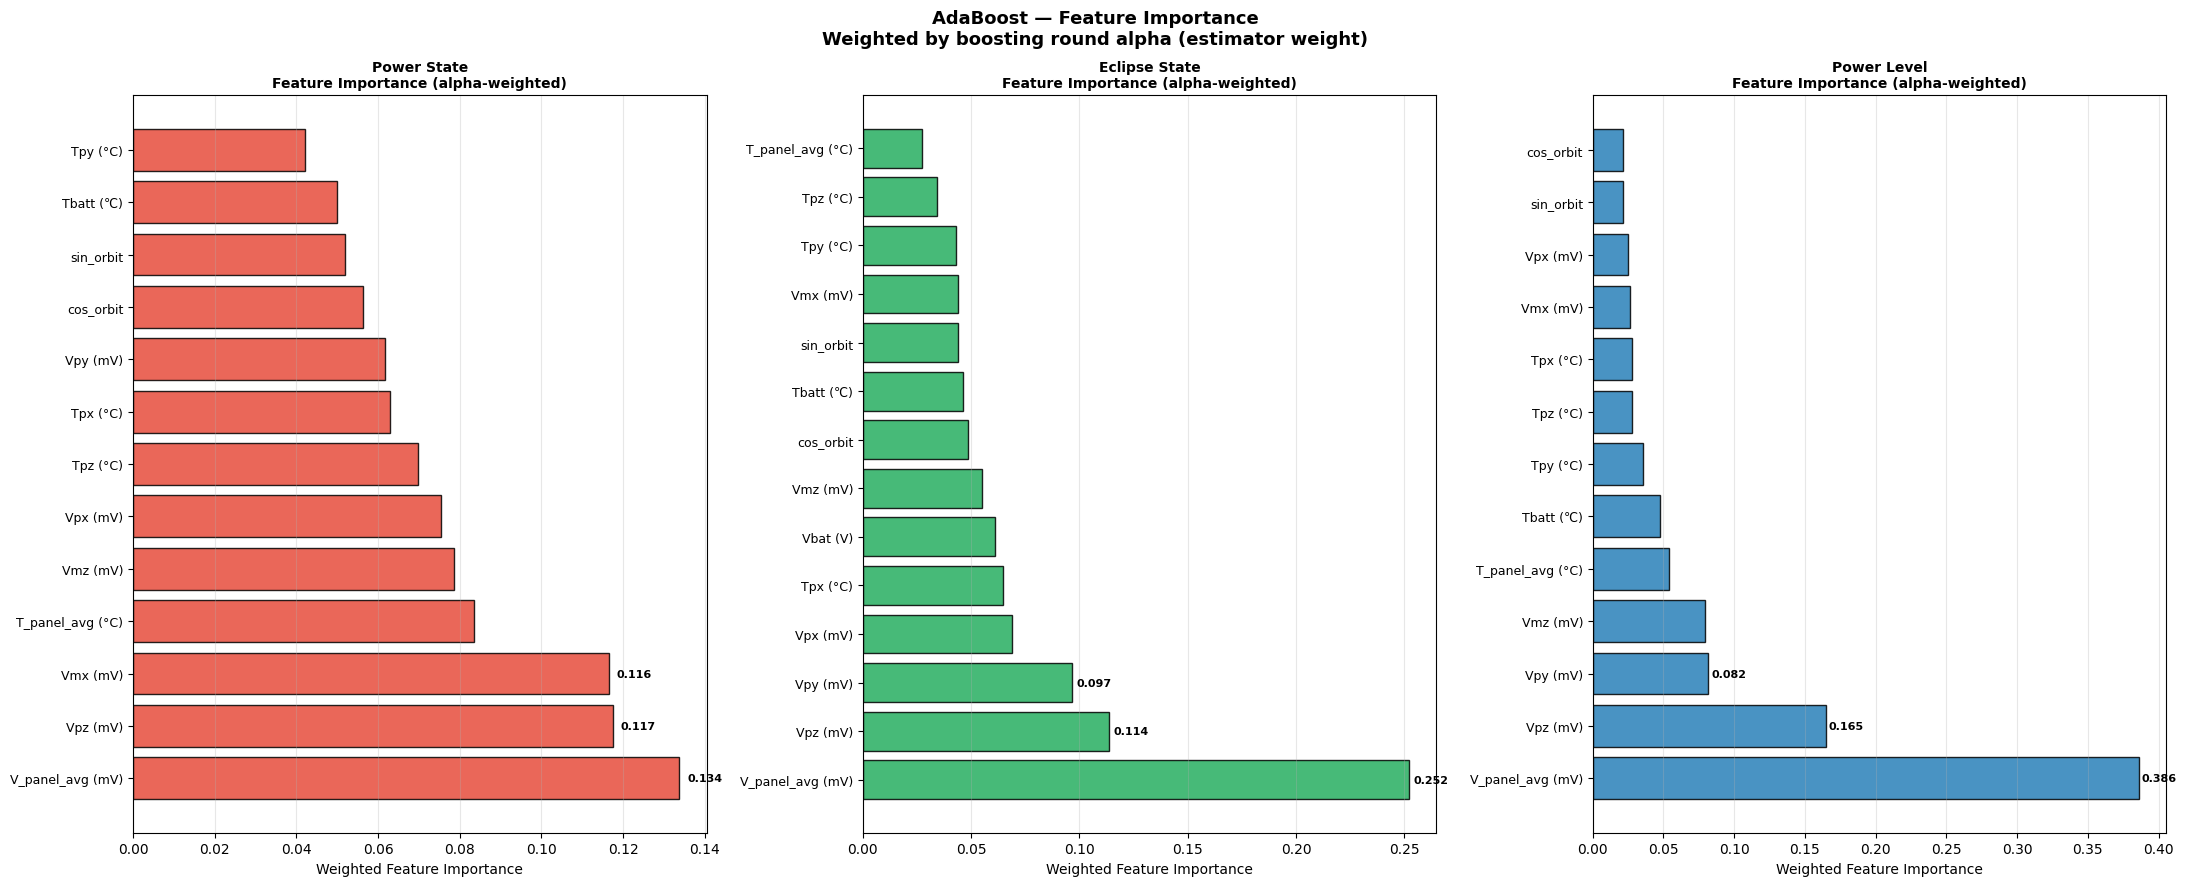

Feature importance plots saved.
Note: Importance weighted by alpha — rounds correcting
harder errors contribute more than early easy rounds.


In [10]:
# ============================================================
# SECTION 8: FEATURE IMPORTANCE — ADABOOST UNIQUE
# AdaBoost importance = weighted sum of feature importances
# across all boosting rounds, weighted by estimator weight (alpha)
# Higher alpha = better performing weak learner in that round
# Unique to AdaBoost vs RF: later rounds (correcting errors)
# have higher alpha and contribute more to importance
# ============================================================

fig, axes = plt.subplots(1, 3, figsize=(22, 9))
fig.suptitle('AdaBoost — Feature Importance\n'
             'Weighted by boosting round alpha (estimator weight)',
             fontsize=13, fontweight='bold')

tnames     = ['Power State', 'Eclipse State', 'Power Level']
bar_colors = ['#e74c3c', '#27ae60', '#2980b9']

for idx, (task, tn, clr) in enumerate(zip(
        datasets.keys(), tnames, bar_colors)):
    model = results_after[task]['model']
    feats = results_after[task]['feats']
    imp   = model.feature_importances_

    # Sort by importance descending
    sort_idx     = np.argsort(imp)[::-1]
    sorted_feats = [feats[i] for i in sort_idx]
    sorted_imp   = imp[sort_idx]

    ax = axes[idx]
    bars = ax.barh(range(len(sorted_feats)), sorted_imp,
                   color=clr, edgecolor='black', alpha=0.85)
    ax.set_yticks(range(len(sorted_feats)))
    ax.set_yticklabels(sorted_feats, fontsize=9)
    ax.set_title(f'{tn}\nFeature Importance (alpha-weighted)',
                 fontweight='bold', fontsize=10)
    ax.set_xlabel('Weighted Feature Importance')
    ax.grid(True, alpha=0.3, axis='x')

    # Annotate top 3
    for i in range(min(3, len(sorted_imp))):
        ax.text(sorted_imp[i]+0.002, i,
                f'{sorted_imp[i]:.3f}',
                va='center', fontsize=8, fontweight='bold')

plt.tight_layout()
plt.savefig('04_feature_importance.png', dpi=72, bbox_inches='tight')
plt.show()
print("Feature importance plots saved.")
print("Note: Importance weighted by alpha — rounds correcting")
print("harder errors contribute more than early easy rounds.")

## Feature Importance (Alpha-Weighted)

AdaBoost importance differs fundamentally from RF — it is weighted
by alpha (estimator weight) of each boosting round. Rounds that
correct harder errors receive higher alpha and contribute more
to importance scores.

**Power State (Left Plot)**
V_panel_avg leads at 0.134 but importance is MORE evenly
distributed than RF (RF had 0.239). Vmx=0.116, Vpz=0.117 —
multiple panel voltages share importance almost equally.
Sequential stumps spread across different features in each
round rather than consistently returning to one dominant feature.
Temperature and orbital features near zero — power state
determined primarily by instantaneous panel voltage readings.

**Eclipse State (Centre Plot)**
V_panel_avg dominates at 0.252 — nearly 2.5x the next feature
(Vpz=0.114). This extreme concentration confirms that every
boosting round selects V_panel_avg as the splitting threshold
because it provides the cleanest separation. Temperature
features (T_panel_avg, Tpz, Tpy) have near-zero importance —
thermal signals add no information beyond voltage.

**Power Level (Right Plot)**
V_panel_avg extremely dominant at 0.386 — 2.3x the next feature
(Vpz=0.165). Most concentrated importance in the entire project.
Depth=3 base learners with 160 boosting rounds keep returning
to V_panel_avg as the primary split, with Vpz and Vpy as
secondary splits. cos_orbit and sin_orbit near zero — orbital
position does not determine instantaneous power level.

5-FOLD TIMESERIES CROSS VALIDATION

Task      : Power_State
Acc Folds : [np.float64(0.9768), np.float64(0.8506), np.float64(0.9523), np.float64(0.9647), np.float64(0.937)]
Acc Mean  : 0.9363 +/- 0.0448
F1 Folds  : [np.float64(0.9762), np.float64(0.839), np.float64(0.946), np.float64(0.9658), np.float64(0.9348)]
F1 Mean   : 0.9324 +/- 0.0489

Task      : Eclipse_State
Acc Folds : [np.float64(0.9992), np.float64(0.9974), np.float64(0.9987), np.float64(0.9992), np.float64(0.9974)]
Acc Mean  : 0.9984 +/- 0.0008
F1 Folds  : [np.float64(0.9992), np.float64(0.9974), np.float64(0.9987), np.float64(0.9992), np.float64(0.9974)]
F1 Mean   : 0.9984 +/- 0.0008

Task      : Power_Level
Acc Folds : [np.float64(0.8344), np.float64(0.8612), np.float64(0.8083), np.float64(0.7905), np.float64(0.8349)]
Acc Mean  : 0.8259 +/- 0.0243
F1 Folds  : [np.float64(0.8338), np.float64(0.8585), np.float64(0.8076), np.float64(0.7926), np.float64(0.8353)]
F1 Mean   : 0.8256 +/- 0.0231


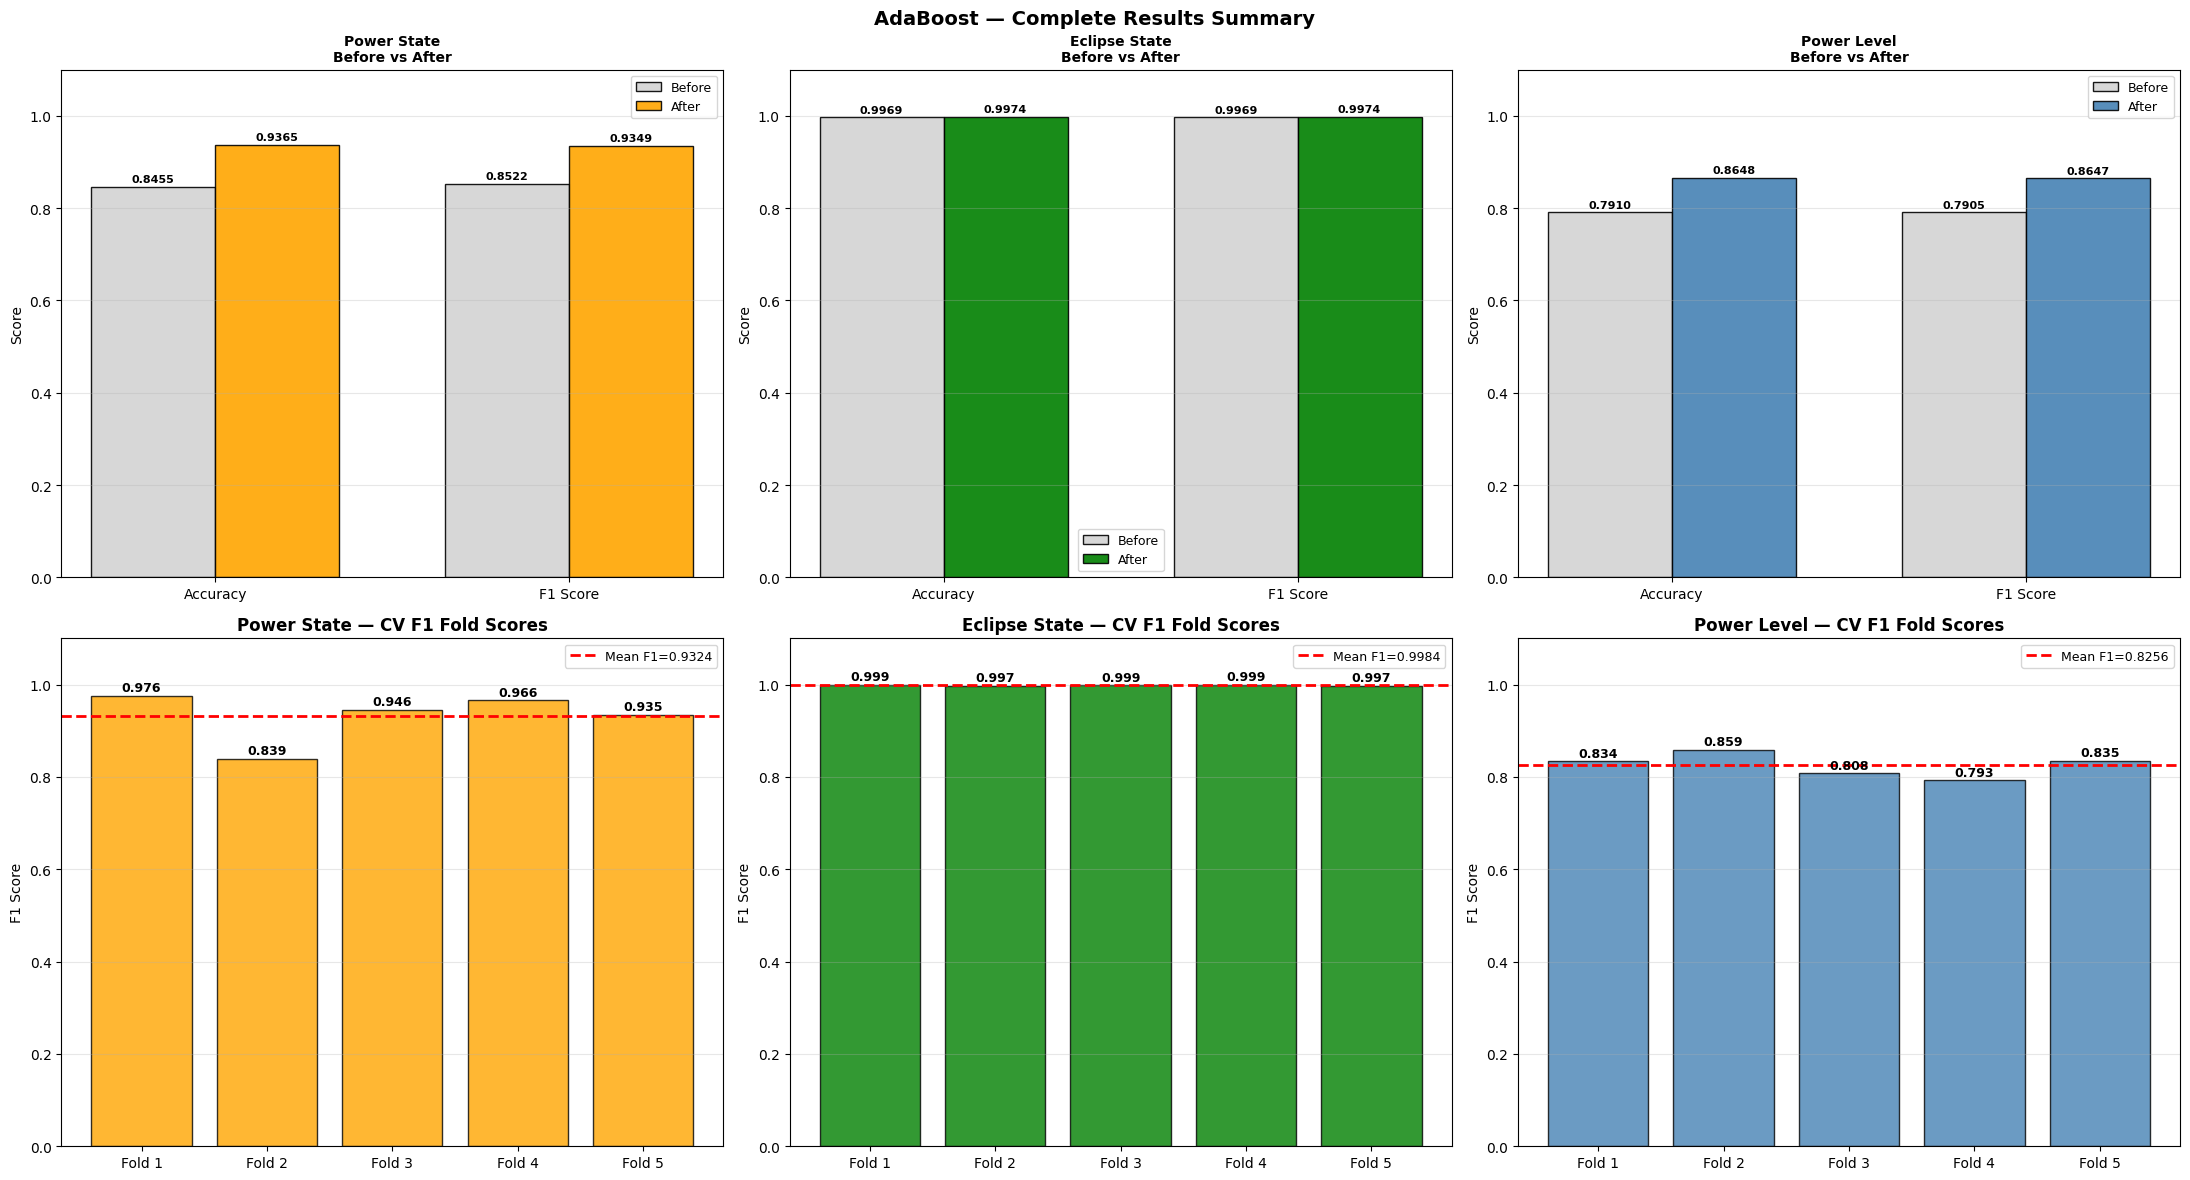

Summary plot saved.


In [12]:
# ============================================================
# SECTION 9: CROSS VALIDATION + COMPLETE SUMMARY
# ============================================================

print("=" * 60)
print("5-FOLD TIMESERIES CROSS VALIDATION")
print("=" * 60)

cv_results = {}

for task, (Xtr, Xte, ytr, yte, feats, scaler, X_full) in datasets.items():
    pipeline = results_after[task]['pipeline']
    X_scaled = scaler1.transform(X_full) if task == 'Power_State' \
        else scaler2.transform(X_full) if task == 'Eclipse_State' \
        else scaler3.transform(X_full)
    y_full   = df['Power_State']   if task == 'Power_State' \
          else df['Eclipse_State'] if task == 'Eclipse_State' \
          else df['Power_Level']

    scores_acc = cross_val_score(pipeline, X_scaled, y_full,
                                  cv=tscv, scoring='accuracy')
    scores_f1  = cross_val_score(pipeline, X_scaled, y_full,
                                  cv=tscv, scoring='f1_weighted')

    cv_results[task] = {'acc': scores_acc, 'f1': scores_f1}

    print(f"\nTask      : {task}")
    print(f"Acc Folds : {[round(s,4) for s in scores_acc]}")
    print(f"Acc Mean  : {scores_acc.mean():.4f} +/- {scores_acc.std():.4f}")
    print(f"F1 Folds  : {[round(s,4) for s in scores_f1]}")
    print(f"F1 Mean   : {scores_f1.mean():.4f} +/- {scores_f1.std():.4f}")

# Summary visualization
fig, axes = plt.subplots(2, 3, figsize=(22, 12))
fig.suptitle('AdaBoost — Complete Results Summary',
             fontsize=14, fontweight='bold')

colors    = ['orange', 'green', 'steelblue']
tnames    = ['Power State', 'Eclipse State', 'Power Level']
fold_lbls = ['Fold 1','Fold 2','Fold 3','Fold 4','Fold 5']

# Row 1: Before vs After
for idx, (task, clr, tn) in enumerate(zip(
        datasets.keys(), colors, tnames)):
    ax    = axes[0, idx]
    b_acc = results_before[task]['acc']
    a_acc = results_after[task]['acc']
    b_f1  = results_before[task]['f1']
    a_f1  = results_after[task]['f1']
    x     = np.arange(2)
    w     = 0.35
    ax.bar(x-w/2, [b_acc, b_f1], w, label='Before',
           color='lightgray', edgecolor='black', alpha=0.9)
    ax.bar(x+w/2, [a_acc, a_f1], w, label='After',
           color=clr, edgecolor='black', alpha=0.9)
    ax.set_xticks(x)
    ax.set_xticklabels(['Accuracy', 'F1 Score'])
    ax.set_title(f'{tn}\nBefore vs After',
                 fontweight='bold', fontsize=10)
    ax.set_ylabel('Score')
    ax.set_ylim([0, 1.1])
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3, axis='y')
    for val, xpos in zip([b_acc, b_f1, a_acc, a_f1],
                          [-w/2, 1-w/2, w/2, 1+w/2]):
        ax.text(xpos, val+0.01, f'{val:.4f}',
                ha='center', fontsize=8, fontweight='bold')

# Row 2: CV F1 fold scores
for idx, (task, clr, tn) in enumerate(zip(
        datasets.keys(), colors, tnames)):
    ax     = axes[1, idx]
    scores = cv_results[task]['f1']
    bars   = ax.bar(fold_lbls, scores, color=clr,
                    edgecolor='black', alpha=0.8)
    ax.axhline(y=scores.mean(), color='red', linestyle='--',
               linewidth=2, label=f'Mean F1={scores.mean():.4f}')
    ax.set_title(f'{tn} — CV F1 Fold Scores', fontweight='bold')
    ax.set_ylabel('F1 Score')
    ax.set_ylim([0, 1.1])
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3, axis='y')
    for bar, val in zip(bars, scores):
        ax.text(bar.get_x()+bar.get_width()/2,
                bar.get_height()+0.01,
                f'{val:.3f}', ha='center',
                fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig('05_summary.png', dpi=72, bbox_inches='tight')
plt.show()
print("Summary plot saved.")

## Cross Validation and Results Summary

### Before vs After (Row 1)
Power State showed the largest tuning improvement in this project
— accuracy +9.1% (0.8455→0.9365), F1 +8.27% (0.8522→0.9349).
Deeper base estimators (depth=5) with optimized learning_rate
transformed the worst Power State base model into competitive
performance. Eclipse State unchanged at 0.9974 — ceiling
performance regardless of parameters. Power Level improved
substantially from 0.7905 to 0.8647 (+7.42%) — the worst
base model in the project became comparable to LR after tuning.

### CV Fold Scores (Row 2)
Power State CV mean=0.9324 ± 0.0489 — highest variance across
all three algorithms (LR=0.0434, RF=0.0149, AdaBoost=0.0489).
Sequential boosting is more sensitive to temporal distribution
shifts than parallel bagging. Fold 2 drops to 0.839 —
early mid-period orbital data disrupts sequential error
correction chains more severely than parallel ensemble trees.

Eclipse State CV mean=0.9984 ± 0.0008 — near identical to RF.
Consistent across all folds confirming the eclipse boundary
is temporally stable throughout the entire mission.

Power Level CV mean=0.8256 ± 0.0231 — lower than RF (0.8598).
Fold 4 drops to 0.7926 — same August-October 2021 orbital
instability seen in all previous notebooks. AdaBoost handles
this worse than RF because sequential error correction chains
break down when training distribution shifts between folds.

## AdaBoost Classifier —  Conclusion

**Dataset:** TSURU CubeSat On-Orbit EPS Data (Jara et al., 2022)
**DOI:** 10.1016/j.dib.2022.108697

---

## Algorithm Summary

AdaBoost builds an ensemble sequentially — each new weak learner
focuses on samples that previous learners misclassified:

> F(x) = Σ αₜ hₜ(x)

Where αₜ is the weight of weak learner hₜ based on its error rate:
> αₜ = 0.5 × ln((1 - εₜ) / εₜ)

Misclassified samples receive higher weight in the next round,
forcing subsequent learners to focus on harder examples.

**Key properties:**
- Sequential learning — each round corrects previous errors
- Weak learners are decision stumps (depth=1) by default
- Deeper base estimators significantly improve performance
- learning_rate shrinks each estimator's contribution
- Feature importance weighted by alpha — harder rounds matter more
- No class_weight parameter — compute_sample_weight applied at fit()

**Imbalance handling:**
compute_sample_weight('balanced') assigns higher weight to CRITICAL
samples at fit() — equivalent to class_weight='balanced' but
passed as sample_weight since AdaBoost does not support
class_weight directly. AdaBoost then additionally upweights
misclassified CRITICAL samples in each boosting round — creating
a double emphasis on the rare CRITICAL class.

---

## Final Results

| Task | n_est | lr | base_depth | Accuracy | F1 Score | CV F1 Mean ± Std |
|------|-------|----|-----------|---------|---------|-----------------|
| Power State | 249 | 1.3221 | 5 | 0.9365 | 0.9349 | 0.9324 ± 0.0489 |
| Eclipse State | 63 | 1.4724 | 2 | 0.9974 | 0.9974 | 0.9984 ± 0.0008 |
| Power Level | 160 | 0.3754 | 3 | 0.8648 | 0.8647 | 0.8256 ± 0.0231 |

---

## Comparison with Previous Classifiers

| Task | LR F1 | RF F1 | AdaBoost F1 | Best |
|------|-------|-------|-------------|------|
| Power State | 0.8650 | 0.9430 | 0.9349 | RF ✅ |
| Eclipse State | 0.9959 | 0.9974 | 0.9974 | RF / AdaBoost tie ✅ |
| Power Level | 0.8599 | 0.8777 | 0.8647 | RF ✅ |

RF leads overall. AdaBoost beats LR on all tasks but
falls slightly short of RF on Power State and Power Level.

---

## Key Findings

### 1 — Largest Tuning Improvement in the Project
Power State F1 improved from 0.8522 to 0.9349 (+8.27%) —
the largest single task improvement from tuning across all
notebooks. Power Level improved from 0.7905 to 0.8647
(+7.42%) — the worst base model transformed by tuning.
This confirms AdaBoost base model is heavily dependent on
base estimator depth and learning_rate selection.

### 2 — Decision Stumps Fundamentally Insufficient
depth=1 F1 for Power Level = 0.728 — completely inadequate.
depth=3 F1 = 0.854 — dramatic 12.6% jump from single depth
increase. Power State depth=1 gives 0.843, depth=5 gives 0.934.
AdaBoost theory assumes weak learners — but too-weak learners
(stumps) cause rapid overfitting and performance collapse
on complex multi-class boundaries.

### 3 — CRITICAL Class: Double Emphasis, Mixed Result
compute_sample_weight + AdaBoost reweighting create double
emphasis on CRITICAL samples. Base model CRITICAL recall=0.49
(better than RF base of 0.05). After tuning recall dropped
to 0.23 — deeper base estimators with high learning_rate
optimize overall boundaries at CRITICAL's expense.
The f1_macro scoring could not fully compensate.

### 4 — Sequential Boosting More Sensitive than Bagging
Power State CV std = 0.0489 vs RF std = 0.0149.
Sequential error correction chains are disrupted by temporal
distribution shifts between folds — if Fold 2 training data
has different distribution, all subsequent boosting rounds
are affected. RF's independent trees absorb these shifts
through averaging, making it more temporally stable.

### 5 — Power Level Learning_rate Sensitivity
lr=0.3 optimal, lr=2.0 causes complete collapse to near F1=0.
No other task or algorithm shows this extreme sensitivity.
The HIGH/MEDIUM overlap creates conflicting gradient signals
that explode at high learning_rate — unique to AdaBoost's
exponential loss function on overlapping class boundaries.

### 6 — V_panel_avg Dominance Increases with Sequential Boosting
AdaBoost Power Level: V_panel_avg importance = 0.386
RF Power Level      : V_panel_avg importance = 0.178
Sequential stumps keep returning to V_panel_avg as the most
discriminative split in every round — RF distributes importance
more evenly because trees use different bootstrap samples.

### 7 — Eclipse State Performance Ceiling Confirmed Again
All depths, all learning_rates, all n_estimators give F1~0.997.
The task is so linearly separable that even the weakest
configuration (depth=1, n=10) achieves near-perfect results.
AdaBoost adds no value over a single decision stump here.

### 8 — Power Level Fold 4 Persists
CV Fold 4 F1 = 0.7926 — same mid-period orbital instability
seen in LR (0.8044) and RF (0.8038). AdaBoost handles it
worse (0.7926) — sequential models are more vulnerable to
distribution shifts than parallel ensemble methods.
This is a persistent data characteristic, not a model issue.

---

## Limitations
- Highest CV variance of all three algorithms (std=0.0489)
- CRITICAL recall dropped after tuning (0.49→0.23)
- Sequential training cannot be parallelized — slowest of
  the three algorithms for same n_estimators
- Extremely sensitive to learning_rate for Power Level
- No class_weight parameter — pipeline complexity increases
- Decision stumps require careful depth tuning to be useful

---

## Next Notebook
**Gradient Boosting Classifier** — sequential boosting using
gradient descent on loss function. Contrast with AdaBoost's
sample reweighting approach using exponential loss.
GBM minimizes arbitrary differentiable loss functions via
gradient descent in function space — more flexible and
typically more robust than AdaBoost's reweighting strategy.

---

*Reference: Jara et al. (2022), Data in Brief, DOI: 10.1016/j.dib.2022.108697*